In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# Navigate from notebooks/ up to project root, then to app/
notebooks_dir = Path.cwd()
project_root = notebooks_dir.parent  # Go up one level from notebooks/
app_path = project_root / 'app'
if str(app_path) not in sys.path:
    sys.path.insert(0, str(app_path))
print(f"Project root: {project_root}")
print(f"App path added: {app_path}")

from services.finance_service import FinanceService  # noqa: E402

Project root: e:\documents\Previsão da bolsa de valores
App path added: e:\documents\Previsão da bolsa de valores\app


In [4]:
bolsa_de_valores = FinanceService()
df_history,_,_,_,_ = bolsa_de_valores.get_historical_data(full=True, ticker='RACE')

In [5]:
df_history

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-10-21 00:00:00-04:00,55.467844,56.364575,50.845524,50.845524,22498800,0.0,0.0
2015-10-22 00:00:00-04:00,52.759161,53.803807,51.492647,52.463333,4545100,0.0,0.0
2015-10-23 00:00:00-04:00,53.406293,53.618919,52.019597,52.121288,1967600,0.0,0.0
2015-10-26 00:00:00-04:00,52.694452,52.694452,50.420271,50.864014,1466300,0.0,0.0
2015-10-27 00:00:00-04:00,50.660636,50.836287,45.631552,49.782394,5949200,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-13 00:00:00-04:00,346.600006,355.660004,345.825989,355.140015,445500,0.0,0.0
2026-04-14 00:00:00-04:00,357.739990,360.380005,357.290009,358.130005,459800,0.0,0.0
2026-04-15 00:00:00-04:00,357.000000,358.190002,354.459991,357.059998,405200,0.0,0.0


In [6]:
# Configuração visual
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)


# Removendo o MultiIndex que o yfinance novo traz às vezes e garantindo o nome das colunas
if isinstance(df_history.columns, pd.MultiIndex):
    df_history.columns = df_history.columns.droplevel(1)

display(df_history.head())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-10-21 00:00:00-04:00,55.467844,56.364575,50.845524,50.845524,22498800,0.0,0.0
2015-10-22 00:00:00-04:00,52.759161,53.803807,51.492647,52.463333,4545100,0.0,0.0
2015-10-23 00:00:00-04:00,53.406293,53.618919,52.019597,52.121288,1967600,0.0,0.0
2015-10-26 00:00:00-04:00,52.694452,52.694452,50.420271,50.864014,1466300,0.0,0.0
2015-10-27 00:00:00-04:00,50.660636,50.836287,45.631552,49.782394,5949200,0.0,0.0


In [7]:

# 1. Cria um DataFrame consolidando as informações da sua base
resumo_df = pd.DataFrame({
    'Tipo de Dado': df_history.dtypes,
    'Valores Não-Nulos': df_history.notnull().sum(),
    'Valores Nulos': df_history.isnull().sum(),
    '% de Nulos': (df_history.isnull().sum() / len(df_history) * 100).round(2)
})

print(f"O dataset possui {df_history.shape[0]} linhas e {df_history.shape[1]} colunas.\n")

# 2. Exibe o resultado como uma tabela formatada. 
# BÔNUS: Adiciona um mapa de calor na coluna de valores nulos!
display(resumo_df)

# 3. Tratamento de nulos (Forward Fill)
if resumo_df['Valores Nulos'].sum() > 0:
    df_history.ffill(inplace=True)
    print("\n✅ Valores nulos preenchidos com o método Forward Fill.")
else:
    print("\n✅ Nenhum valor nulo encontrado. Base limpa!")

O dataset possui 2637 linhas e 7 colunas.



,Tipo de Dado,Valores Não-Nulos,Valores Nulos,% de Nulos
Open,float64,2637,0,0.0
High,float64,2637,0,0.0
Low,float64,2637,0,0.0
Close,float64,2637,0,0.0
Volume,int64,2637,0,0.0
Dividends,float64,2637,0,0.0
Stock Splits,float64,2637,0,0.0



✅ Nenhum valor nulo encontrado. Base limpa!


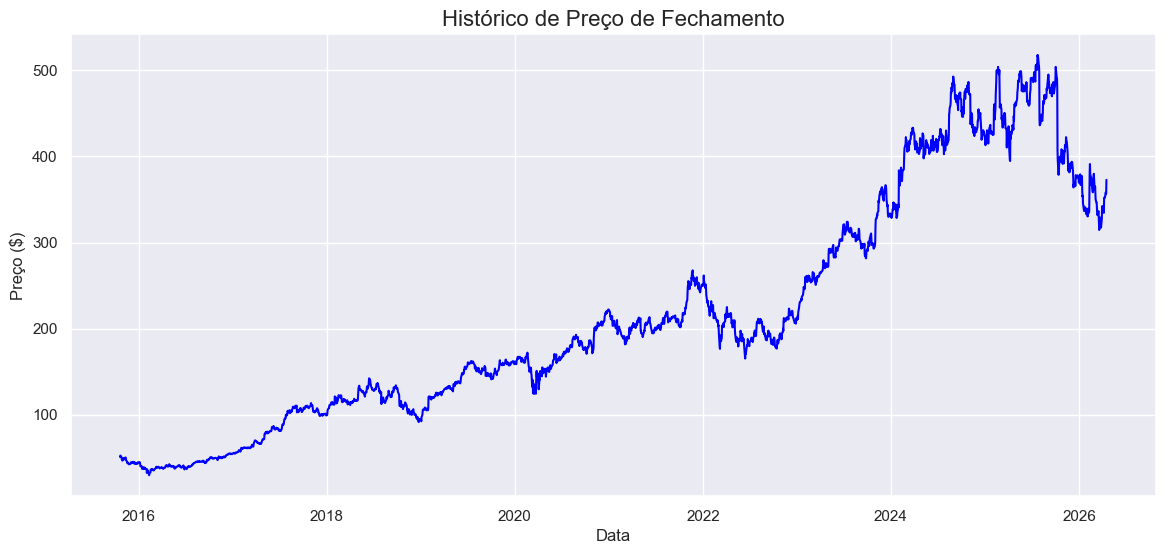

In [ ]:
plt.plot(df_history.index, df_history['Close'], color='blue', linewidth=1.5)
plt.title('Histórico de Preço de Fechamento', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Preço ($)')
plt.show()

### Histórico de Fechamento

Olhando o gráfico desde 2016 vemos que a ação se valorizou muito no longo prazo mostrando que os dados não são estacionários  e possui uma forte e contínua tendência de alta no longo prazo, O que significa que o preço não fica orbitando em volta de um único valor médio. 
Pensando no modelo, ele não pode simplesmente tirar uma média do passado, ele precisa entender e acompanhar a as mudanças que acontecem nos dados.

**mudança de regime (Comportamento)** 
* **2016 a 2020 :** Vemos um período de crescimento constante, relativamente tranquilo e equilibrado, sem grandes picos ou quedas, o que indica que as correções de preço são curtas e a volatilidade é visivelmente contida.

* **2022 :** O mercado financeiro teve uma mudança direcional, onde começa uma descida durante o ano, quebrando o ritmo de alta perfeito que vinha antes.

* **2024 em diante :** Os preços começam a subir com volatilidade, amplitude e oscilações que mostram um aumento nas negociações onde a ação passa a variar dezenas de dólares em poucos dias e logo no limite do gráfico, sofre uma queda muito aguda e repentina.

**O Desafio para a nossa IA:** O nosso algoritmo precisa ser treinado para entender que o mercado atual esta mudando não podendo dar o mesmo peso para todo o histórico. Se o modelo se basear muito em como a ação se comportava lá em 2018 (quando o cenário era mais calmo e previsível), ele vai errar as previsões de hoje. Ele precisa ter flexibilidade para focar no comportamento agitado recente e não ficar ancorado no passado, o que exigirá hiperparâmetros que priorizem a memória de curto prazo e que tenham flexibilidade suficiente na linha de tendência para se adaptar rapidamente a quebras estruturais, como a queda aguda observada no final do período.


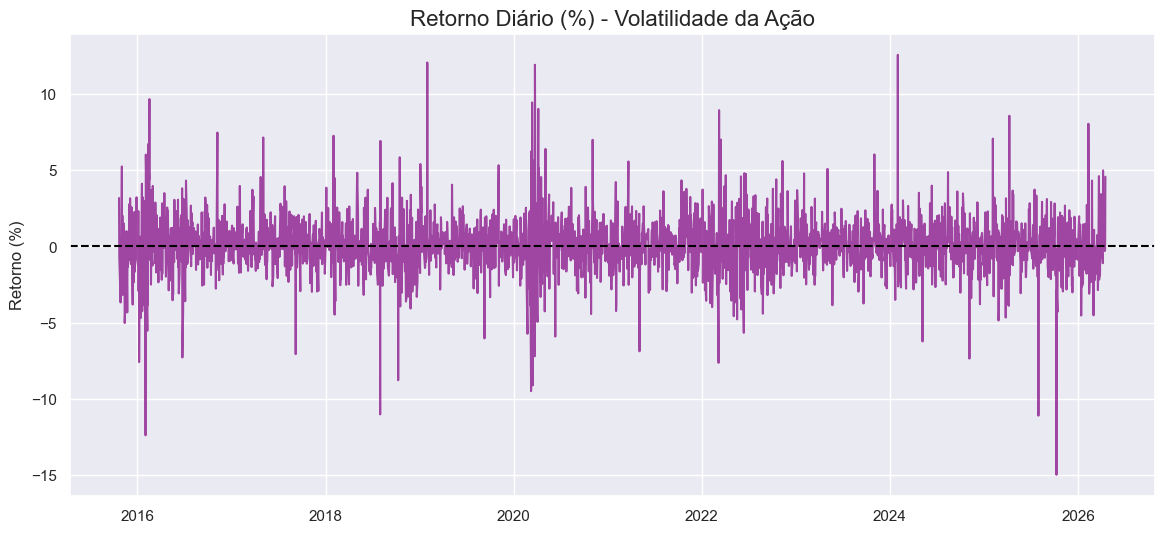

In [21]:
# Calculando a variação percentual diária
df_history['Retorno_Diario'] = df_history['Close'].pct_change() * 100

plt.plot(df_history.index, df_history['Retorno_Diario'], color='purple', alpha=0.7)
plt.title('Retorno Diário (%) - Volatilidade da Ação', fontsize=16)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Retorno (%)')
plt.show()

### 2. Retorno Diário e Volatilidade

Com este gráfico conseguimos olhar para a *velocidade* em que o preço muda isolando o comportamento direcional do preço e focando puramente na variação percentual diária da ação. A linha central tracejada é o "zero" (um dia em que a ação não subiu nem caiu). As agulhas mostram as variações diárias em porcentagem.


**O Comportamento Observado:**
A principal constatação visual é que o nível de instabilidade da ação não se mantem igual ao longo dos anos.
* **Fases de Estabilidade:** Entre 2017 e 2019, as oscilações eram curtas e contidas, geralmente não passando do padrão de uma certa faixa ao dia.
* **Fases de Extrema Volatilidade:** Em 2020 e no período de 2024 a 2026, as variações mudam drasticamente, chegando a mostrar quedas ou altas bem superiores em um único dia.
**Agrupamento de Volatilidade:**
Repare que as mudanças diárias não acontecem isoladas. Dias de grandes quedas costumam ser seguidos por dias de grandes altas. Os investidores agem em um efeito de manada, criando esses blocos de alta volatilidade.



**Impacto na Modelagem e Feature Engineering:**
A principal implicação é que modelos que costumam assumir a variância constante do erro poderão falhar ao prever intervalos de confiança precisos, então precisamos ter cuidado, senão o modelo assumirá uma margem de erro "padrão" para o projeto inteiro. 
Não podemos fornecer apenas o retorno passado absoluto. Precisamos construir **sensores de regime dinâmicos**. Isso exige a injeção de *features* como o **Desvio Padrão Móvel (Rolling Standard Deviation)** de janelas curtas (ex: 7 e 14 dias), permitindo que o algoritmo perceba quando o ativo entra em um cluster de alta volatilidade e ajuste o peso e a cautela de suas predições adequadamente.


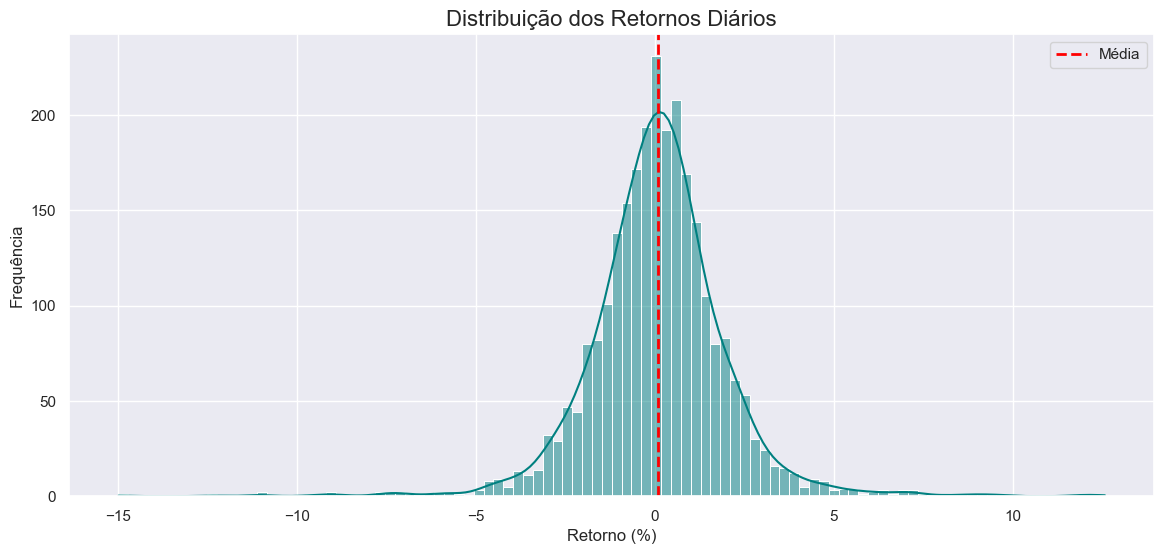

In [22]:
sns.histplot(df_history['Retorno_Diario'].dropna(), bins=100, kde=True, color='teal')
plt.title('Distribuição dos Retornos Diários', fontsize=16)
plt.xlabel('Retorno (%)')
plt.ylabel('Frequência')
plt.axvline(df_history['Retorno_Diario'].mean(), color='red', linestyle='dashed', linewidth=2, label='Média')
plt.legend()
plt.show()

### Distribuição dos Retornos
Podemos ver o histograma das variações percentuais diárias da ação. Ele organiza o histórico de retornos em faixas de distribuição para revelar a frequência exata com que cada nível de oscilação ocorre. A linha vermelha tracejada demarca a média histórica do ativo, que se posiciona muito próxima a zero.
Conforme vamos para os cantos direito e esquerdo, vemos os dias de altas ou baixas.

**A Teoria vs. A Realidade (As Caudas Grossas):**
A distribuição real dos retornos da Ferrari foge do padrão teórico de uma Curva Normal (Gaussiana) perfeita. O gráfico exibe um perfil claramente para uma distribuição que desvia da normalidade (Leptocúrtico), caracterizado por dois fatores estruturais:
* **Hiperconcentração Central:** A esmagadora maioria dos pregões registra variações mínimas, criando aquele pico agudo no centro do eixo. O mercado, na maior parte do tempo, opera em inércia.
* **Caudas Grossas (Fat Tails):** A base do gráfico se estende horizontalmente para níveis de ±10% e além. Em uma distribuição normal pura, a probabilidade desses eventos extremos seria quase nula. O gráfico prova matematicamente que choques severos de preço acontecem com uma frequência muito maior do que a estatística clássica prevê.


**O Impacto para a Inteligência Artificial:**
O principal impacto deste gráfico é um alerta contra o uso de premissas estatísticas ingênuas. Modelos preditivos lineares simples assumem distribuições normais; se os utilizarmos, a nossa IA subestimará sistematicamente o risco financeiro real, sendo "surpreendida" por eventos extremos.

Para garantir a robustez da nossa arquitetura, o modelo escolhido precisará lidar naturalmente com *outliers* sem degradar sua performance. É por isso que algoritmos baseados em particionamento (como XGBoost e LightGBM) ou transformações matemáticas não-lineares nos dados de entrada são escolhas superiores para este projeto: eles conseguem mapear a alta probabilidade das "caudas grossas" sem comprometer o aprendizado dos dias de estabilidade.


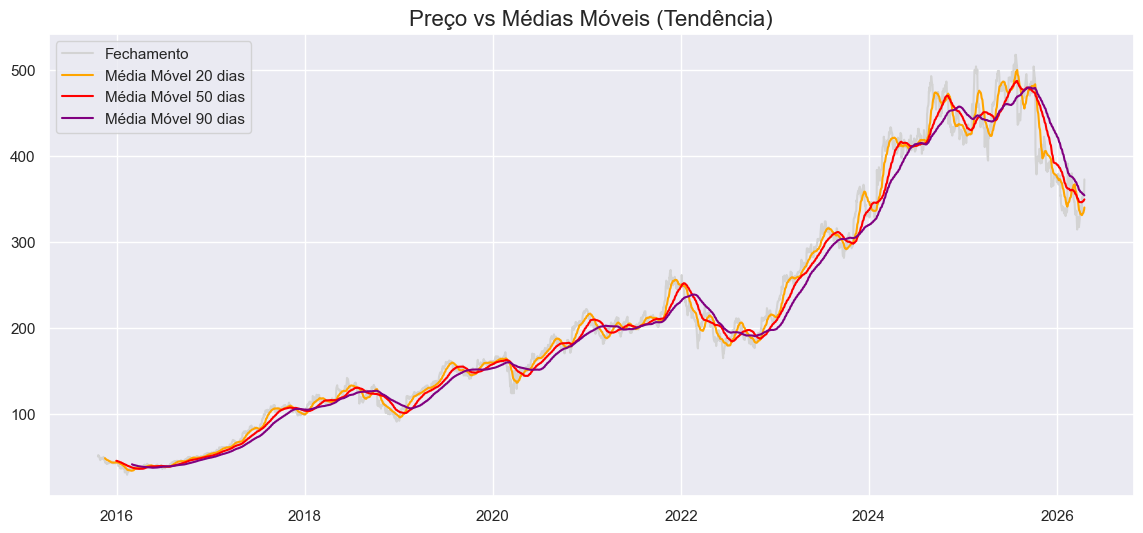

In [11]:
df_history['MA_20'] = df_history['Close'].rolling(window=20).mean() # Curto prazo (1 mês útil)
df_history['MA_50'] = df_history['Close'].rolling(window=50).mean() # Médio prazo
df_history['MA_90'] = df_history['Close'].rolling(window=90).mean() # longo prazo

plt.plot(df_history.index, df_history['Close'], label='Fechamento', color='lightgrey')
plt.plot(df_history.index, df_history['MA_20'], label='Média Móvel 20 dias', color='orange')
plt.plot(df_history.index, df_history['MA_50'], label='Média Móvel 50 dias', color='red')
plt.plot(df_history.index, df_history['MA_90'], label='Média Móvel 90 dias', color='purple')
plt.title('Preço vs Médias Móveis (Tendência)', fontsize=16)
plt.legend()
plt.show()

### 4. Preço vs Médias Móveis
Aqui estamos sobrepondo o preço bruto de fechamento (linha cinza) a três Médias Móveis Simples (SMA - *Simple Moving Averages*) de diferentes janelas temporais: 20 dias (curto prazo), 50 dias (médio prazo) e 90 dias (longo prazo). A aplicação destas médias atua como um filtro, atenuando a variância diária (ruído) para revelar a direção primária do ativo (sinal).

**A Bússola do Risco:**
Onde está o ouro deste gráfico? Na distância entre o preço atual e as linhas suaves. Se o preço da Ferrari dispara e fica muito acima da linha roxa, significa que a ação "esticou demais", como um elástico, e o risco de uma queda forte para voltar à média (correção) é gigante. 

A relação espacial entre o preço e estas médias nos permite diagnosticar o estágio atual do mercado:
* **Alinhamento e Inércia:** Em períodos de forte tendência (como 2020-2021 e 2024), observa-se um padrão claro onde o Preço > SMA 20 > SMA 50 > SMA 90. Esse espaçamento paralelo indica forte inércia direcional.
* **Reversão à Média (Mean Reversion):** A distância entre o preço absoluto e as médias mais longas atua como um rastreador de anomalias. Quando o ativo se distancia drasticamente da média de 90 dias (um estado de sobrecompra ou sobrevenda), a probabilidade estatística de uma correção abrupta para buscar o reequilíbrio aumenta consideravelmente.
* **Mudança de Regime (Crossovers):** O cruzamento das médias de curto prazo cruzando para baixo das médias de longo prazo (como visto na correção de 2022 e na queda aguda recente) sinaliza inflexões estruturais no comportamento do mercado.


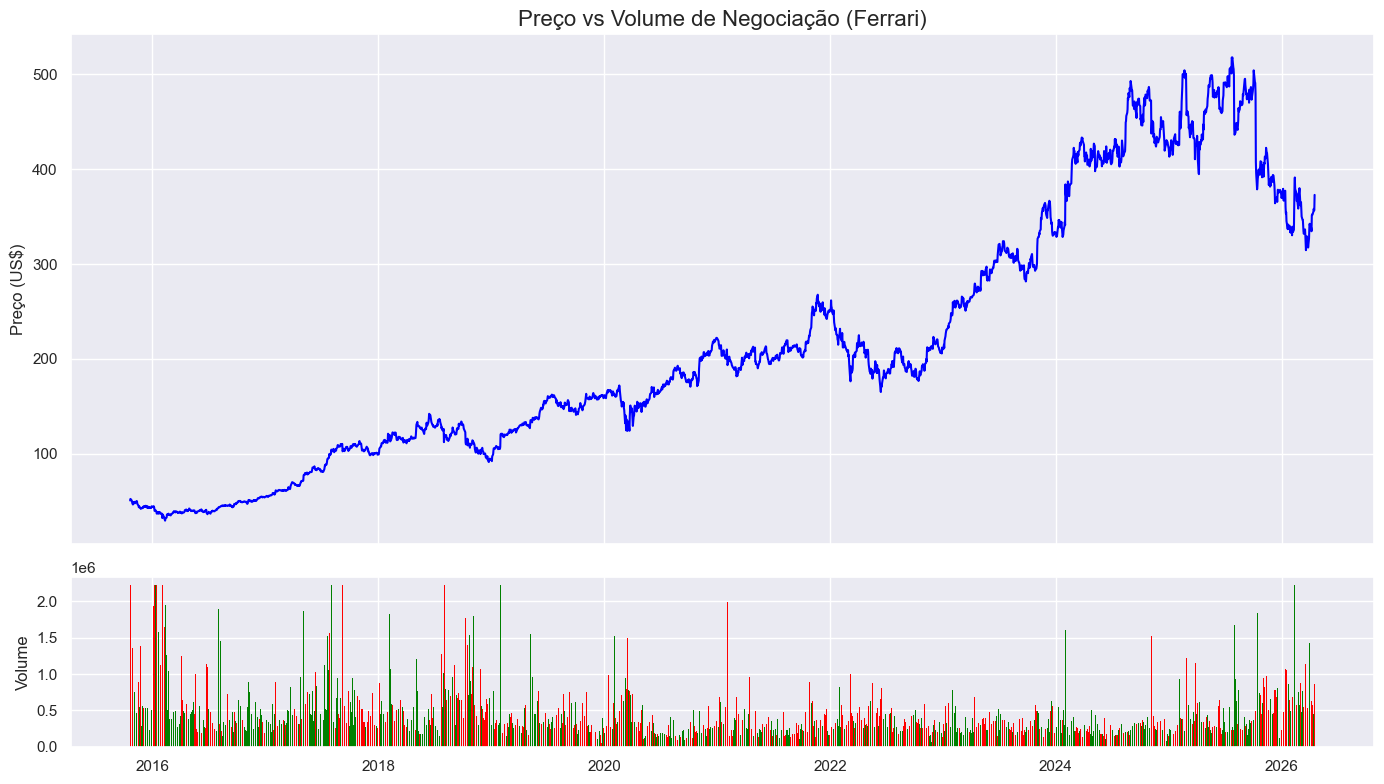

In [20]:

fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]}, figsize=(14, 8), sharex=True)

# 1. Gráfico de Preço
ax1.plot(df_history.index, df_history['Close'], color='blue', linewidth=1.5)
ax1.set_title('Preço vs Volume de Negociação (Ferrari)', fontsize=16)
ax1.set_ylabel('Preço (US$)')

# 2. Preparação do Volume (Clipping e Cores)
colors = np.where(df_history['Close'] < df_history['Open'], 'red', 'green')
teto_volume = df_history['Volume'].quantile(0.99)
volume_vis = np.clip(df_history['Volume'], a_min=0, a_max=teto_volume)

# 3. Gráfico de Volume (Desenhado apenas uma vez com os dados achatados)
ax2.bar(df_history.index, volume_vis, color=colors, width=1.0, linewidth=0)
ax2.set_ylabel('Volume')

plt.tight_layout()
plt.show()

### 5. Dinâmica de Preço e Volume (Validação Direcional e Liquidez)

**O que o gráfico mostra:**
Este painel duplo correlaciona a evolução do preço (painel superior) com a quantidade de ações negociadas diariamente (painel inferior). As barras de volume sinalizam a intensidade do fluxo de ordens executadas no pregão, servindo como uma métrica direta da liquidez e do nível de participação institucional no ativo.

**O Comportamento Observado (Validação de Sinal):**
A análise bidimensional destas variáveis permite ao Cientista de Dados diferenciar movimentos estruturais de ruídos temporários:
* **Movimentos com Alta Liquidez (Volume Elevado):** Quando uma forte oscilação de preço (seja um rompimento de resistência ou uma queda abrupta) é acompanhada por picos de volume, constata-se alta convicção direcional. Isso indica processos de acumulação ou distribuição por grandes *players* institucionais, sugerindo que o movimento tem inércia para se sustentar.
* **Movimentos com Baixa Liquidez (Volume Deprimido):** Variações de preço isoladas, não confirmadas por um aumento no volume, indicam ausência de fluxo institucional. Matematicamente, costumam representar "falsos rompimentos" (*false breakouts*) ou correções técnicas de baixa força, carregando uma probabilidade muito maior de reversão à média.

**O Impacto na Modelagem e Feature Engineering:**
O maior ponto cego de modelos univariados básicos (que analisam exclusivamente a série de preços) é a incapacidade de distinguir um movimento estrutural de um choque sem liquidez. 

Para que algoritmos mais avançados na nossa esteira de MLOps (como LightGBM ou Redes Neurais) consigam validar a força por trás do preço, a nossa arquitetura deve incorporar ativamente a dimensão do fluxo. Como o volume nominal muda de escala com o tempo, não utilizaremos a métrica bruta. Em vez disso, geraremos *features* estacionárias, como a **Razão do Volume Atual vs. SMA de Volume (Ex: Volume de hoje / Média de Volume de 20 dias)** ou o indicador **OBV (On-Balance Volume)**. Essas variáveis atuarão como filtros de convicção direcional na camada de aprendizado do modelo.

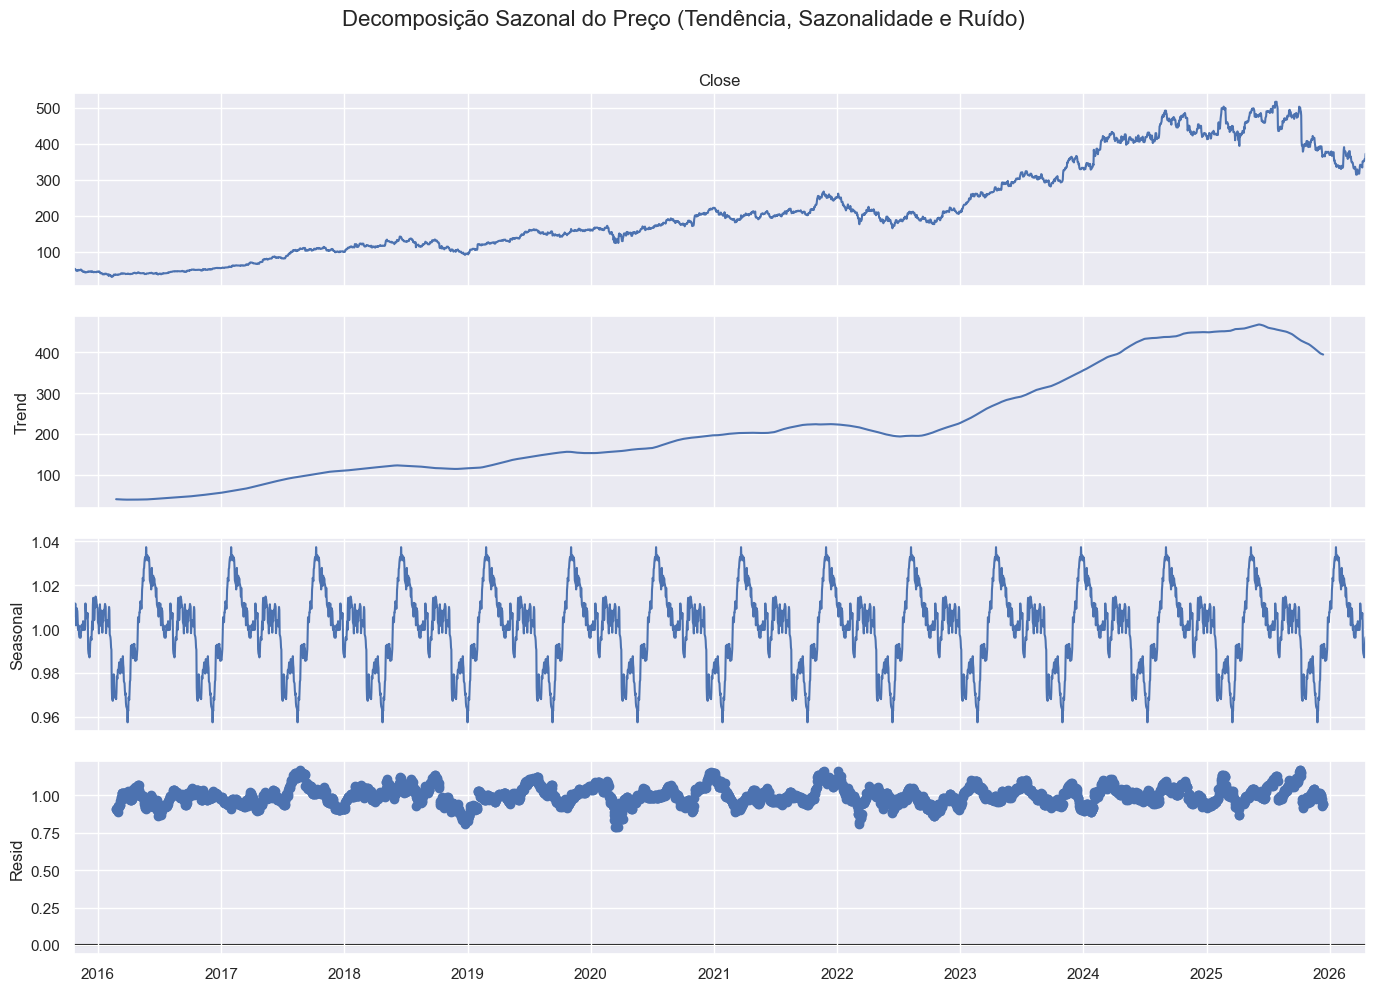

In [13]:
# A decomposição precisa que os dados não tenham buracos (finais de semana)
# Vamos preencher os dias sem pregão temporariamente apenas para esta visualização
df_decomp = df_history[['Close']].resample('D').ffill()

# Decompondo (Assumindo sazonalidade anual de ~252 dias úteis)
decomposicao = seasonal_decompose(df_decomp['Close'].dropna(), model='multiplicative', period=252)

fig = decomposicao.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Decomposição Sazonal do Preço (Tendência, Sazonalidade e Ruído)', fontsize=16, y=1.02)
plt.show()

### 6. Decomposição Sazonal (Extração de Componentes Estruturais)

**O que o gráfico mostra:**
Este painel aplica um algoritmo de decomposição estrutural sobre a série temporal de fechamento (`Close`), desmembrando o sinal bruto em três vetores matemáticos independentes: Tendência (baixa frequência), Sazonalidade (frequência fixa) e Resíduos (componente estocástico). A escala dos painéis inferiores (orbitando em torno de 1.0) indica o uso de uma decomposição **multiplicativa**, o que é matematicamente correto para esta série, visto que a amplitude da volatilidade da Ferrari cresceu proporcionalmente ao aumento do preço ao longo dos anos.

**Análise dos Componentes:**
* **Tendência (Trend):** Isola a direção primária do ativo removendo o ruído e os efeitos de calendário. Ela mapeia claramente os ciclos macroeconômicos de longo prazo, confirmando a inflexão aguda (reversão) no topo histórico mais recente.
* **Sazonalidade (Seasonal):** Extrai os padrões cíclicos que se repetem em intervalos fixos (intra-anuais). A existência destas ondas regulares prova que há um "efeito calendário" no preço da ação, provavelmente ditado por ciclos de divulgação de balanços trimestrais e sazonalidade de vendas do setor automotivo.
* **Resíduos (Resid):** Representa a variância não-explicada — choques exógenos e anomalias de mercado. Observa-se que a dispersão dos pontos residuais engorda e afina em diferentes períodos, confirmando a não-homogeneidade da variância (heteroscedasticidade) diagnosticada nos gráficos de volatilidade.

**O Impacto na Modelagem e Feature Engineering:**
Este gráfico é o mapa arquitetônico exato de como algoritmos da família GAM (*Generalized Additive Models*), como o **Prophet**, processam séries temporais. O Prophet modela nativamente a curva de tendência e aplica séries de Fourier para replicar o componente sazonal, ignorando o ruído.

No entanto, para avaliar modelos *Tree-Based* (como LightGBM e XGBoost) ou *Deep Learning* (LSTMs) no nosso pipeline de MLOps, essa decomposição traz uma exigência de engenharia de dados: como essas arquiteturas não decompõem o tempo nativamente, seremos forçados a "ensinar" a sazonalidade a eles. Faremos isso extraindo as variáveis de calendário do índice de datas (mês, trimestre, dia da semana) e aplicando **Codificação Cíclica (transformações de Seno e Cosseno)**, garantindo que o algoritmo consiga reproduzir matematicamente as ondas sazonais vistas neste painel.

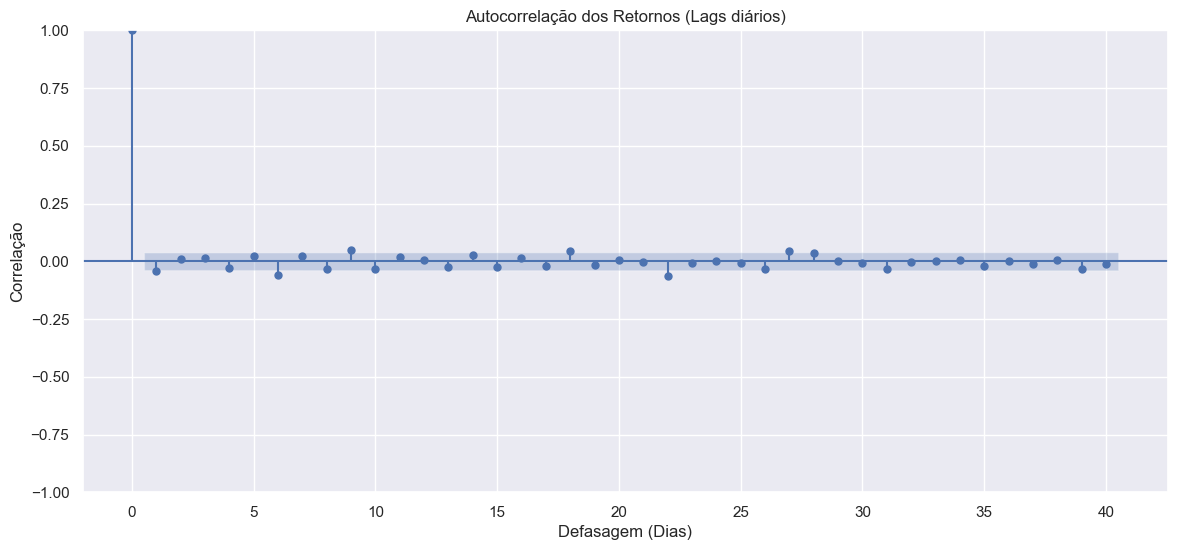

In [14]:
# Plotando a autocorrelação dos retornos (usar o preço absoluto gera falsa correlação)
plot_acf(df_history['Retorno_Diario'].dropna(), lags=40, alpha=0.05, title='Autocorrelação dos Retornos (Lags diários)')
plt.xlabel('Defasagem (Dias)')
plt.ylabel('Correlação')
plt.show()
# Se as barras azuis passarem da área sombreada, significa que há correlação estatisticamente significante.

### 7. Função de Autocorrelação (ACF) e Memória da Série

**O que o gráfico mostra:**
Este correlograma exibe a Função de Autocorrelação (ACF) dos retornos diários. Ele quantifica o grau de correlação linear entre o retorno do ativo no tempo atual ($t$) e seus próprios retornos em defasagens passadas ($t-k$, ou *lags*). A área horizontal sombreada em azul representa o intervalo de confiança estatística (tipicamente 95%).

**O Comportamento Observado (Inexistência de Memória Linear):**
A constatação estatística mais crítica deste painel é que, com exceção do Lag 0 (a correlação do dado consigo mesmo, sempre 1.0), **todos os coeficientes de defasagem (do Lag 1 ao 40) situam-se dentro da banda de insignificância estatística**. 

Matematicamente, isso comprova que o retorno de hoje não possui dependência linear direta com o retorno de ontem (Lag 1) ou da semana passada (Lag 5). A série de retornos da Ferrari assemelha-se a um processo de "Ruído Branco" (*White Noise*), aderindo fortemente à hipótese de Passeio Aleatório (*Random Walk*). 

**O Impacto na Modelagem e Feature Engineering:**
Este diagnóstico decreta a ineficácia de abordagens puramente autorregressivas simples (como alimentar uma Regressão Linear ou um modelo de ML apenas com o preço exato de $D-1$ e $D-2$). Se o fizermos, o algoritmo tentará extrair padrão de um ruído estatístico, resultando em poder preditivo nulo (*overfitting* no treino e falha no teste).

A ausência de autocorrelação linear justifica tecnicamente toda a nossa estratégia prévia de *Feature Engineering*. Para que modelos baseados em Árvores (XGBoost) ou Redes Neurais encontrem sinal preditivo, eles não podem depender do preço isolado de ontem. Eles dependem de **agregações de estado** — é exatamente por isso que calculamos as Médias Móveis (inércia direcional) e o Desvio Padrão Móvel (sensores de mudança de regime e agrupamento de volatilidade). O modelo aprenderá a prever com base no contexto macro do ativo, e não na variação isolada do dia anterior.

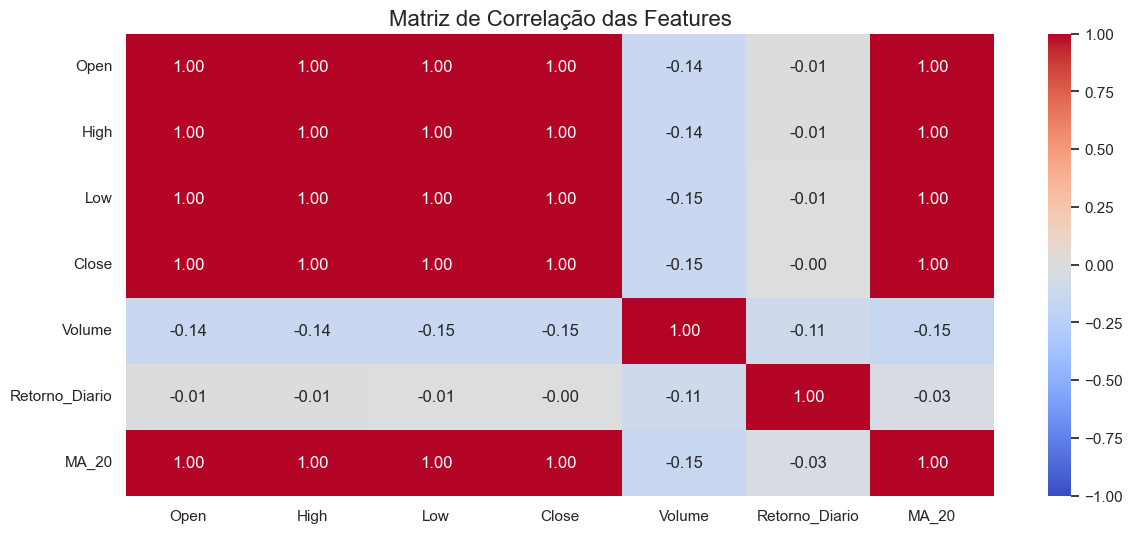

In [15]:
# Selecionando apenas as variáveis contínuas
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Retorno_Diario', 'MA_20']
matriz_corr = df_history[features].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlação das Features', fontsize=16)
plt.show()

### 8. Matriz de Correlação Linear (Diagnóstico de Multicolinearidade)

**O que o gráfico mostra:**
Este painel apresenta um mapa de calor dos coeficientes de correlação de Pearson entre as variáveis (features) do dataset. A métrica varia de -1 a 1 e quantifica o grau de dependência linear entre cada par de variáveis.

**O Comportamento Observado (Redundância e Ortogonalidade):**
A matriz revela duas características estruturais fundamentais da nossa base de dados:
* **Multicolinearidade Extrema:** As variáveis que descrevem o preço absoluto (`Open`, `High`, `Low`, `Close`) e a Média Móvel (`MA_20`) exibem uma correlação perfeita ou quase perfeita (1.00) entre si. Do ponto de vista algébrico, elas são vetores colineares; representam exatamente a mesma dimensão de informação.
* **Informação Independente (Sinal Ortogonal):** Em contrapartida, o `Retorno_Diario` e o `Volume` apresentam correlações muito baixas (próximas a 0 ou levemente negativas) com as variáveis de preço absoluto. Isso atesta que essas métricas carregam informações novas e estatisticamente independentes do preço de fechamento.

**O Impacto na Modelagem e Feature Engineering:**
Este diagnóstico valida matematicamente a nossa estratégia de Seleção de Variáveis (*Feature Selection*) e Redução de Dimensionalidade. 

Injetar `Open`, `High`, `Low` e `Close` simultaneamente no algoritmo não aumenta o poder preditivo do modelo. Pelo contrário, a multicolinearidade severa penaliza modelos lineares tradicionais (causando instabilidade na inversão de matrizes de peso) e adiciona ruído computacional desnecessário a modelos baseados em Árvores. 

A decisão arquitetônica exigida aqui é o descarte (*drop*) das variáveis redundantes, mantendo exclusivamente o `Close` como âncora de preço. O espaço computacional economizado será direcionado para as *features* derivadas que mapeamos anteriormente (Lags, Distância de Médias, Desvio Padrão Móvel e OBV), garantindo que o modelo consuma um dataset enxuto, de alta densidade informacional e altamente protegido contra *overfitting*.

---

## 🧠 Síntese Geral e Arquitetura de Feature Engineering (Abordagem Multi-Modelo)

A Análise Exploratória de Dados (EDA) mostrou que o histórico de preços da ação é complexo: ele tem uma forte tendência de alta, sofre mudanças bruscas de comportamento (*Concept Drift*) e possui períodos onde o risco aumenta e diminui em blocos (*Volatility Clustering*).

Como vamos testar algoritmos muito diferentes — **Prophet**, **XGBoost/LightGBM** e **Deep Learning (LSTMs)** —, não podemos simplesmente passar o preço exato da ação para eles. Modelos baseados em árvores de decisão, por exemplo, não conseguem prever valores maiores do que os que viram no treinamento. Se o preço máximo histórico foi US$ 500, o modelo nunca vai prever US$ 510.

Por isso, o objetivo desta etapa é transformar os dados brutos (*Feature Engineering*) para que os modelos foquem em aprender o comportamento do mercado, e não o valor exato do preço.

### 1. Transformação da Variável-Alvo (*Target*)
O modelo não vai tentar prever o preço final, mas sim a variação desse preço.
* **Retorno Logarítmico (*Log Returns*):** Vamos usar a fórmula matemática `np.log(Close_t / Close_{t-1})`. Isso estabiliza as variações ao longo dos anos e é o padrão do mercado financeiro para analisar ativos.
* **Target Binário:** Criaremos uma coluna indicando apenas a direção: `1` (subiu) e `0` (caiu). Em muitos casos, prever corretamente a direção do mercado dá mais lucro do que acertar o valor exato do retorno.

### 2. Memória do Passado (*Lagged Features*)
Modelos como o XGBoost não entendem naturalmente que os dados estão em uma linha do tempo sequencial. Precisamos criar colunas que guardem o passado recente.
* **Lags de Retorno:** Criaremos colunas com o retorno de 1, 2, 3 e 5 dias atrás. Isso ajuda o algoritmo a encontrar padrões no comportamento recente da ação.

### 3. Osciladores e Momento
Trocar os preços por indicadores percentuais evita que passemos informações repetidas para o modelo e o ajuda a aprender mais rápido.
* **Afastamento da Média:** Usaremos a fórmula `(Close / Média Móvel) - 1` para janelas de 9, 21 e 50 dias. Isso mostra ao modelo, em porcentagem, o quanto a ação subiu ou caiu em relação à sua própria média, indicando se ela está "esticada" demais.
* **RSI (*Relative Strength Index*):** Um indicador que vai de 0 a 100 e mede a força das negociações recentes. Ele ajuda a identificar quando a ação está sobrecomprada (cara no curto prazo) ou sobrevendida.

### 4. Sensores de Risco Dinâmico
Precisamos dar ao modelo colunas que funcionem como alertas, para que ele saiba se o mercado está calmo ou agitado naquele momento.
* **Rolling Volatility:** O desvio padrão móvel dos retornos nos últimos 14 e 30 dias. É uma medida matemática direta do risco atual.
* **Largura das Bandas de Bollinger:** Mede a distância entre a banda superior e a inferior. Quando as bandas ficam muito estreitas, geralmente é um aviso estatístico de que um movimento forte de preço está prestes a acontecer.

### 5. Dimensão de Liquidez (Volume)
Usaremos o volume de negociações para confirmar se um movimento de preço é forte de verdade ou apenas um desvio temporário sem peso no mercado.
* **OBV (*On-Balance Volume*):** Um indicador que soma o volume nos dias de alta e subtrai nos dias de baixa. Se o preço sobe, mas o OBV cai, o modelo percebe que o movimento está perdendo força de compra.
* **Anomalia de Volume:** A divisão entre o volume de hoje e a média de volume dos últimos 10 dias. Ajuda o modelo a detectar entradas repentinas de grandes investidores institucionais.

### 6. Engenharia de Calendário (*Cyclical Encoding*)
O modelo não pode receber os meses do ano apenas como números de 1 a 12. Se fizermos isso, ele vai achar que o mês 12 (Dezembro) está matematicamente muito longe do mês 1 (Janeiro).
* **Transformação Trigonométrica:** Usaremos funções de seno e cosseno para transformar os dias e meses em um formato circular. Isso ensina ao algoritmo, especialmente em Deep Learning, que o fim de um ano está diretamente colado ao início do outro.

---

### 🏛️ Diretrizes de Pré-Processamento por Modelo

Como cada modelo trabalha de um jeito estruturalmente diferente, a preparação final dos dados será dividida em três caminhos no nosso código:

1. **Para o Prophet:** Ele receberá apenas a coluna de data e a de preço exato. O próprio Prophet cuida de isolar a tendência e a sazonalidade usando a sua matemática interna.
2. **Para o XGBoost / LightGBM:** Eles receberão o *Target* (Retorno Logarítmico) e todas as variáveis criadas acima. Não precisaremos normalizar os dados (mudar a escala), porque modelos baseados em árvore de decisão não são afetados por diferenças de escala.
3. **Para Deep Learning (LSTMs):** Receberão todas as variáveis, mas precisaremos aplicar uma normalização estrita (como o *StandardScaler*). Redes neurais precisam que todos os dados estejam na mesma escala base para que consigam aprender corretamente. Além disso, os dados serão formatados em blocos tridimensionais (janelas deslizantes de tempo).